# Shadowing simulation

This notebook shows a more extensive example using a 3-layer dynamic field architecture (perception, planning, memory). We specifically perform a very simple simulation of a shadowing experiment, which takes the following sequence of trials.

1. **Baseline** (1 trial): Response input only at position +3.
2. **Shadowing** (10 trials): Perception at +1 (interlocutor) + response at +3. Raw perception→planning coupling shifts the planning peak toward the interlocutor. Memory accumulates shifted peaks.
3. **Washout** (1 trial): Response only. Accumulated memory biases planning peak toward +1.

Note that perception→planning uses raw coupling (`sigmoid=False`) rather than sigmoid-gated. This gives the perception field enough drive to shift the planning peak during shadowing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyphonplan import FieldSystem, Targets, TaskDynamics
from pyphonplan.viz import plot_field_heatmap

## Field system setup

Three-layer architecture:
- **Planning** (gamma-gated): self-sustaining peaks form only when direct input arrives
- **Memory**: accumulates above-threshold planning traces; persists across trials (`tau_decay=1000`)
- **Perception**: fast field driven by auditory input

We also specify coupling from memory-to-planning and perception-to-planning. The weights are set to reproduce the predicted patterns; this represents a considerable degree-of-freedom in simulation results, so I would try to approach these parameters with some constraints in mind.

In [2]:
sys = FieldSystem(x_min=-10, x_max=10, step_size=0.05)

# Planning field (gamma-gated)
kp = dict(c_exc=4, c_inh=1, c_global=0.5, sigma_exc=1.0, sigma_inh=2.0)
sys.add_field("planning", tau=25, h=-2, kernel_params=kp, gamma_gated=True)

# Memory field
km = dict(c_exc=4, c_inh=1, c_global=0.0, sigma_exc=1.0, sigma_inh=2.0)
sys.add_field(
    "memory", tau=150, h=0, kernel_params=km,
    field_type="memory", tau_decay=1000, source_field="planning"
)

# Perception field
kperc = dict(c_exc=4, c_inh=1, c_global=0.5, sigma_exc=1.0, sigma_inh=2.0)
sys.add_field("perception", tau=10, h=-2, kernel_params=kperc)

# Couplings
sys.add_coupling("memory", "planning", weight=10.0)
sys.add_coupling("perception", "planning", weight=10.0, sigmoid=False)

## Simulation parameters

Response at +3, perception at +1 (2-unit gap within excitatory kernel range, sigma_exc=1.0). Inputs are sequential: perception [0, 100], response [100, 200]. Note that truly sequential inputs is somewhat unrealistic, but may reflect a persistent input effect even as production begins.

The perception field's finite time constant (tau=10) means its activation persists briefly into the response window, providing directional bias during planning peak formation.

We use capitals here following Python's PEP 8 recommendations for module-level constants, but this isn't essential!

In [3]:
RESPONSE_POS = 3.0
PERCEPTION_POS = 1.0

T_START, T_END = 0, 300
PERCEPT_ON, PERCEPT_OFF = 0, 100
RESPONSE_ON, RESPONSE_OFF = 100, 200

RESPONSE_AMP = 30
PERCEPTION_AMP = 40

N_SHADOW = 10

## Trial loops

We define a custom loop that implements (1) a baseline trial; (2) shadowing trials x10; (3) a washout trial. Note that memory state persists automatically between `solve()` calls (unless stated otherwise; see docstrings for details).

In [4]:
def run_trial(sys, has_perception=False, label=""):
    """Run one trial, return copies of field activations."""
    sys.clear_inputs()
    sys.add_input(
        "planning", "response",
        amplitude=RESPONSE_AMP, position=RESPONSE_POS, width=1,
        start=RESPONSE_ON, end=RESPONSE_OFF,
    )
    if has_perception:
        sys.add_input(
            "perception", "auditory",
            amplitude=PERCEPTION_AMP, position=PERCEPTION_POS, width=1,
            start=PERCEPT_ON, end=PERCEPT_OFF,
        )
    sys.solve(t_start=T_START, t_end=T_END)
    return {
        "label": label,
        "planning": sys.activation["planning"].copy(),
        "memory": sys.activation["memory"].copy(),
        "perception": sys.activation["perception"].copy(),
        "time": sys.time.copy(),
        "x": sys.x.copy(),
    }

## Run experimental blocks

In [5]:
trials = []

# Block 1: Baseline (response only)
trials.append(run_trial(sys, has_perception=False, label="baseline"))

# Block 2: Shadowing (perception + response)
for i in range(N_SHADOW):
    trials.append(run_trial(sys, has_perception=True, label=f"shadow_{i+1}"))

# Block 3: Washout (response only)
trials.append(run_trial(sys, has_perception=False, label="washout"))

print(f"Ran {len(trials)} trials: {[t['label'] for t in trials]}")

Ran 12 trials: ['baseline', 'shadow_1', 'shadow_2', 'shadow_3', 'shadow_4', 'shadow_5', 'shadow_6', 'shadow_7', 'shadow_8', 'shadow_9', 'shadow_10', 'washout']


## Planning field heatmaps

Compare baseline, last shadowing trial, and washout. During shadowing the planning peak is pulled toward the perception position (+1). In washout, accumulated memory produces a smaller but visible shift.

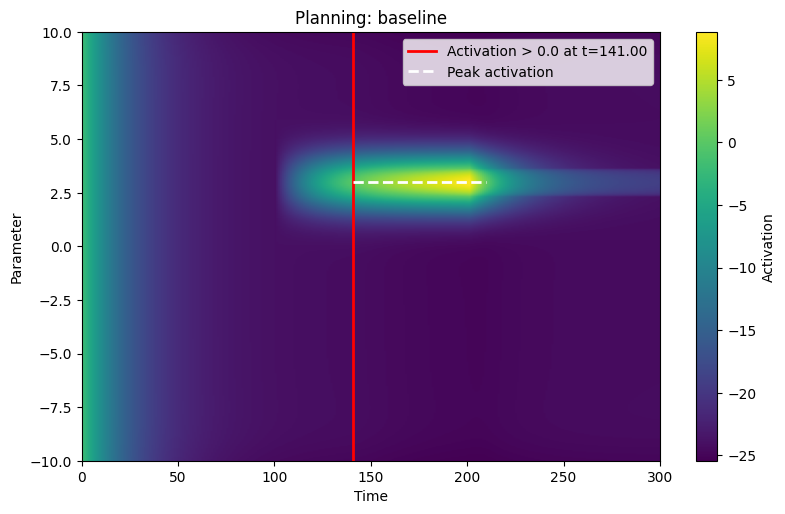

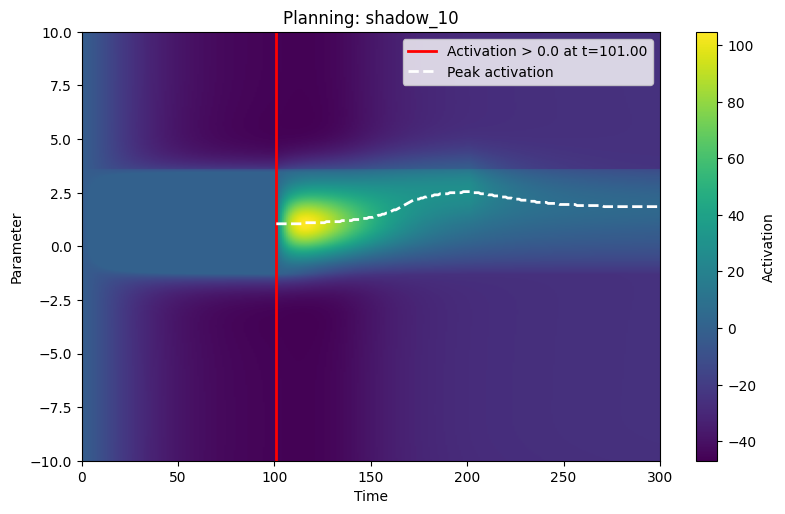

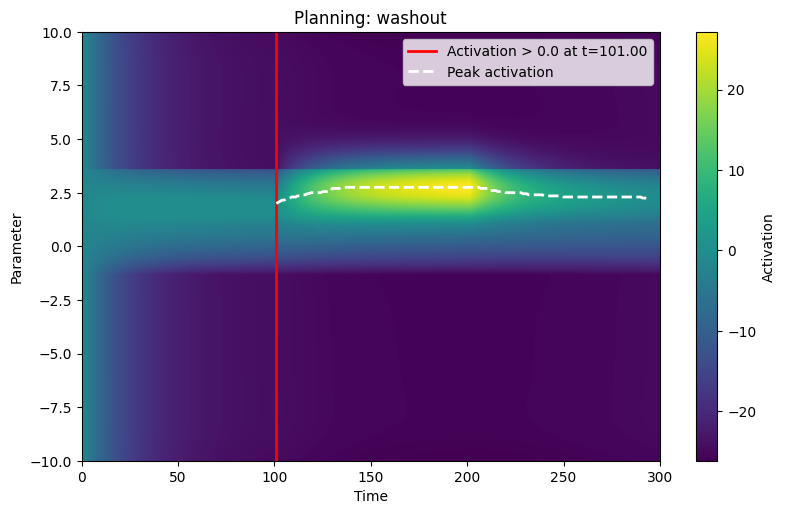

In [6]:
show_trials = [
    ("baseline", trials[0]),
    (f"shadow_{N_SHADOW}", trials[N_SHADOW]),
    ("washout", trials[-1]),
]

for label, trial in show_trials:
    plot_field_heatmap(
        trial["time"], trial["x"], trial["planning"],
        title=f"Planning: {label}",
    )

## Memory: end-of-trial profiles

Compare 1D memory profiles at the end of each block. The specific patterns are difficult to see on the heatmaps, so let's examine 1D profiles on the same axes. This shows the asymmetric memory accumulation directly. The memory profile has got a lot broader, showing the recent influence of perception on production and how this influences memory.

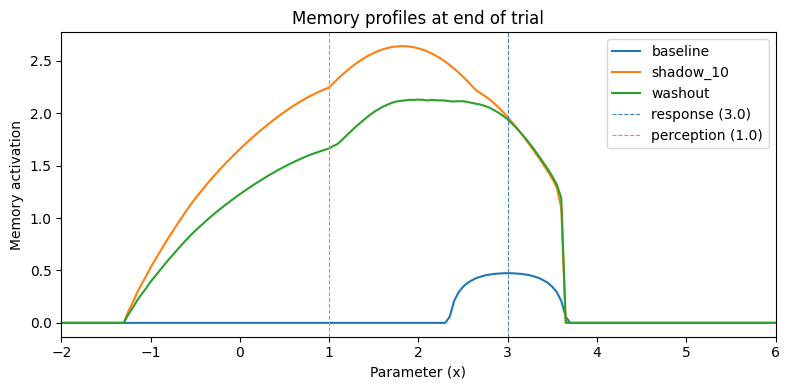

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, trial in [("baseline", trials[0]),
                     (f"shadow_{N_SHADOW}", trials[N_SHADOW]),
                     ("washout", trials[-1])]:
    mem_profile = trial["memory"][:, -1]
    ax.plot(trial["x"], mem_profile, label=label)

ax.axvline(RESPONSE_POS, color="steelblue", ls="--", lw=0.8, label=f"response ({RESPONSE_POS})")
ax.axvline(PERCEPTION_POS, color="coral", ls="--", lw=0.8, label=f"perception ({PERCEPTION_POS})")
ax.set_xlabel("Parameter (x)")
ax.set_ylabel("Memory activation")
ax.set_title("Memory profiles at end of trial")
ax.set_xlim(-2, 6)
ax.legend()
plt.tight_layout()
plt.show()

## Peak location analysis

Measure peak activation location during the **response plateau** (t=120–180) only, avoiding transient peak formation and sub-threshold artefacts. This is a little heuristic, but it's useful to have some way of identifying a single value per token that we can compare across trials.

In [8]:
def measure_plateau_peak(trial, t_lo=120, t_hi=180):
    """Mean peak position during the response plateau window."""
    targets = Targets(sys, activation=trial["planning"])
    pp, ap, t = targets.peak_activation(above_threshold=False)
    mask = (t >= t_lo) & (t <= t_hi) & (ap >= 0)
    if not np.any(mask):
        return np.nan
    return np.mean(pp[mask])


plateau_peaks = []
labels = []
for trial in trials:
    plateau_peaks.append(measure_plateau_peak(trial))
    labels.append(trial["label"])

bl_plateau = plateau_peaks[0]
wo_plateau = plateau_peaks[-1]

print("Plateau peak positions (t=120-180):")
for lbl, pk in zip(labels, plateau_peaks):
    print(f"  {lbl:>12s}: {pk:.3f}")

Plateau peak positions (t=120-180):
      baseline: 3.000
      shadow_1: 1.563
      shadow_2: 1.548
      shadow_3: 1.530
      shadow_4: 1.506
      shadow_5: 1.511
      shadow_6: 1.520
      shadow_7: 1.516
      shadow_8: 1.516
      shadow_9: 1.515
     shadow_10: 1.514
       washout: 2.709


The plot shows the baseline production at +3. The virtual speaker converges considerably during the shadowing task, with perception strongly influencing production (we set the perception coupling high because of the nature of this task). The washout value (no perception) is below the initial baseline, showing a small amount of transfer from the shadowing trials that persists post-shadowing.

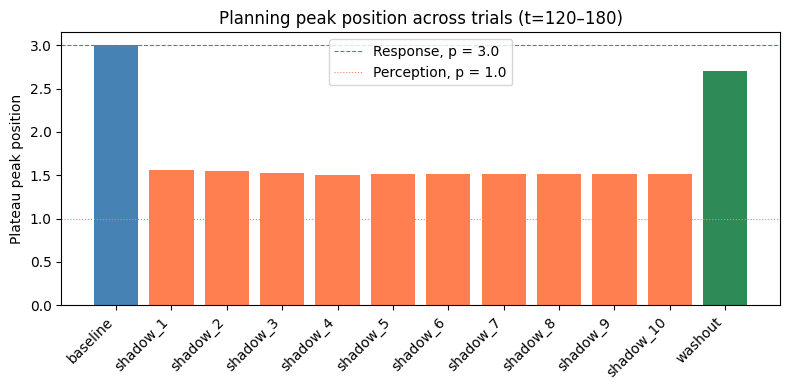

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
colours = ["steelblue"] + ["coral"] * N_SHADOW + ["seagreen"]
ax.bar(range(len(plateau_peaks)), plateau_peaks, color=colours)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Plateau peak position")
ax.set_title("Planning peak position across trials (t=120–180)")
ax.axhline(RESPONSE_POS, color="steelblue", lw=0.8, ls="--", label=f"Response, p = {RESPONSE_POS}")
ax.axhline(PERCEPTION_POS, color="coral", lw=0.8, ls=":", label=f"Perception, p = {PERCEPTION_POS}")
ax.legend()
plt.tight_layout()
plt.show()

## Task dynamics: baseline vs washout

We can now drive task dynamics with fixed targets from the plateau peak measurements rather than the full above-threshold activation trace. Again, this is heuristic to simplify the analysis. One particular problem with this simulation is that a strong perception influence can result in a faster onset of activation, because when the response input arrives there is already considerable sub-threshold activation. This accurately predicts faster reaction times, because input durations are fixed, the above-threshold duration can differ between baseline and shadowing trials. As a result, we extract the plateau peak location and use it as a constant gestural target. In future work, it may be more principled to integrate feedback for input cessation, such as condition of satisfaction.

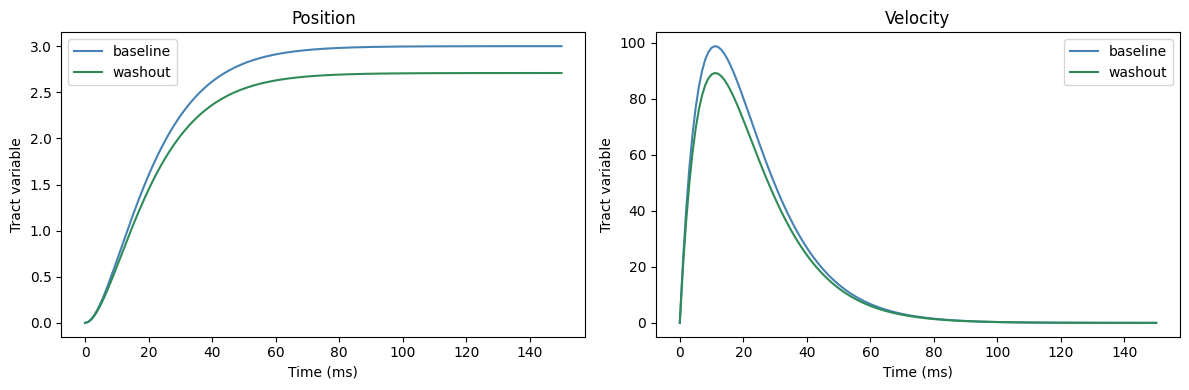

In [10]:
GESTURE_DUR = 0.15  # seconds

td_baseline = TaskDynamics(t_start=0, t_end=GESTURE_DUR, initial_position=0.0)
td_baseline.add_gesture(target=bl_plateau, k=8000, start=0.0, end=GESTURE_DUR)
td_baseline.solve()

td_washout = TaskDynamics(t_start=0, t_end=GESTURE_DUR, initial_position=0.0)
td_washout.add_gesture(target=wo_plateau, k=8000, start=0.0, end=GESTURE_DUR)
td_washout.solve()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(td_baseline.time * 1000, td_baseline.position, label="baseline", color="steelblue")
axes[0].plot(td_washout.time * 1000, td_washout.position, label="washout", color="seagreen")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Tract variable")
axes[0].set_title("Position")
axes[0].legend()

axes[1].plot(td_baseline.time * 1000, td_baseline.velocity, label="baseline", color="steelblue")
axes[1].plot(td_washout.time * 1000, td_washout.velocity, label="washout", color="seagreen")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Tract variable")
axes[1].set_title("Velocity")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

Finally, we can return precise summary values for comparison.

In [11]:
peak_shift = wo_plateau - bl_plateau
tv_shift = td_washout.position[-1] - td_baseline.position[-1]

print(f"Baseline plateau peak:  {bl_plateau:.3f}")
print(f"Washout plateau peak:   {wo_plateau:.3f}")
print(f"Peak shift:             {peak_shift:.3f}")

Baseline plateau peak:  3.000
Washout plateau peak:   2.709
Peak shift:             -0.291
